# project


[1] 42065
Year: 2019 | Residential : {Average:  32126.75 , Variance:  186103016.25 , Standard Deviation: 13641.9579331561 Correlation: 0.131662587826956 , Median: 33542 , IQR: 19899.75 Normalization: 7.06498660032903 Quartiles: { 16481 , 25019 , 42065 } Mode: 42065 }
[1] 16333
Year: 2019 | Commercial : {Average:  11730.25 , Variance:  33948492.9166667 , Standard Deviation: 5826.53352488996 Correlation: 0.169161807659468 , Median: 12744.5 , IQR: 8382.25 Normalization: 6.03974041334716 Quartiles: { 4717 , 9156 , 16333 } Mode: 16333 }
[1] 10999
Year: 2019 | Government : {Average:  9495.75 , Variance:  9492127.58333333 , Standard Deviation: 3080.92966218532 Correlation: 0.33696508294685 , Median: 10356 , IQR: 2721.25 Normalization: 9.24631624981463 Quartiles: { 5122 , 9713 , 10999 } Mode: 10999 }
[1] 6939
Year: 2019 | Industrial : {Average:  14131.25 , Variance:  228549698.916667 , Standard Deviation: 15117.8602625063 Correlation: 0.0809332449594757 , Median: 10318 , IQR: 13762.25 Normaliz

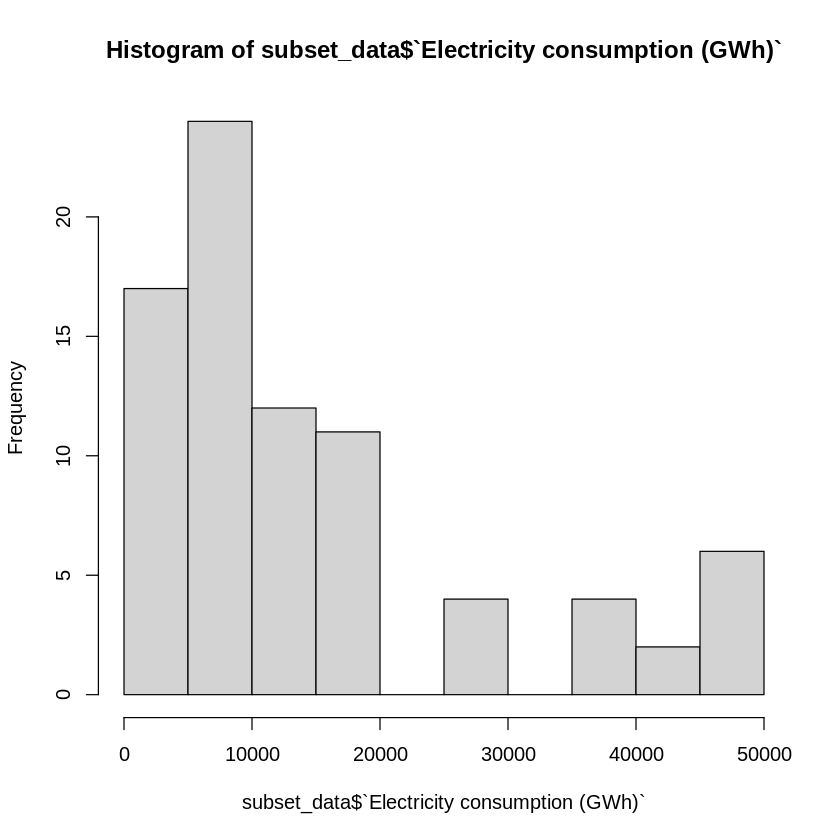

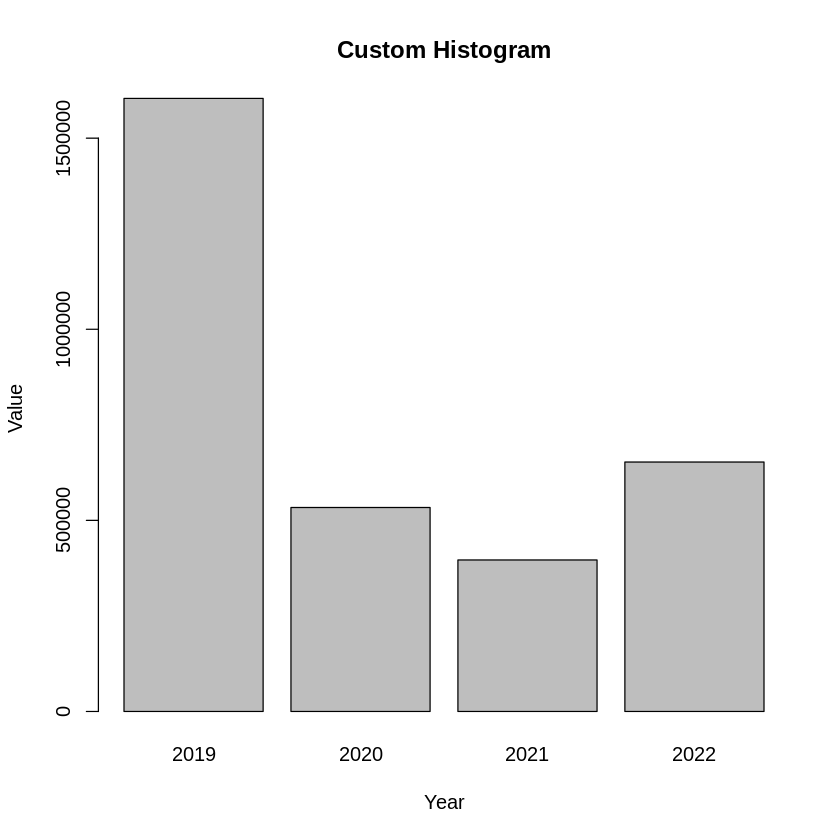

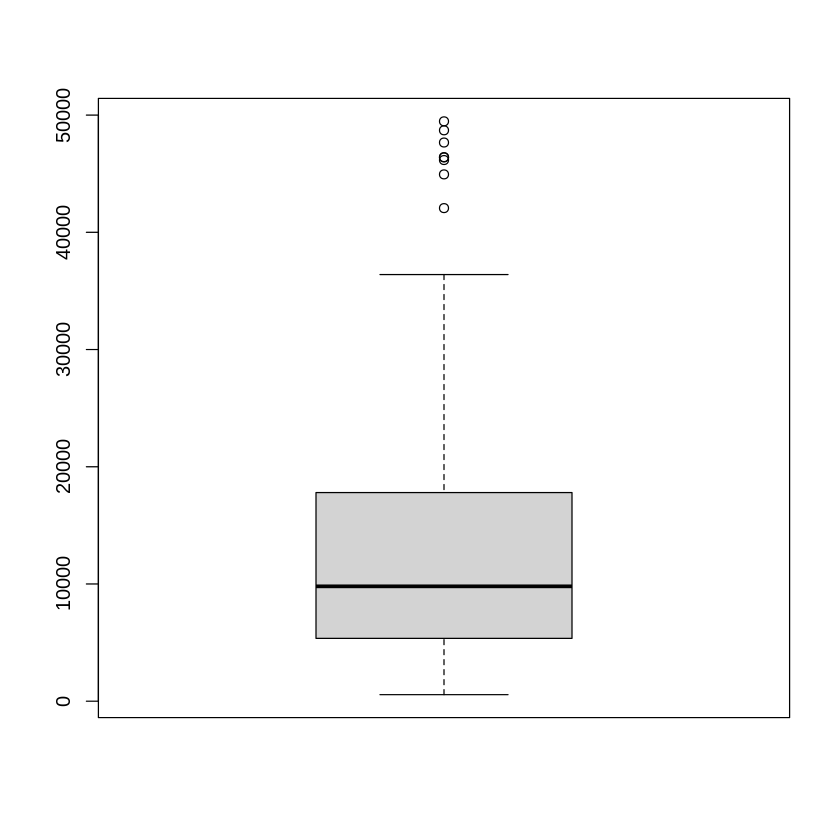

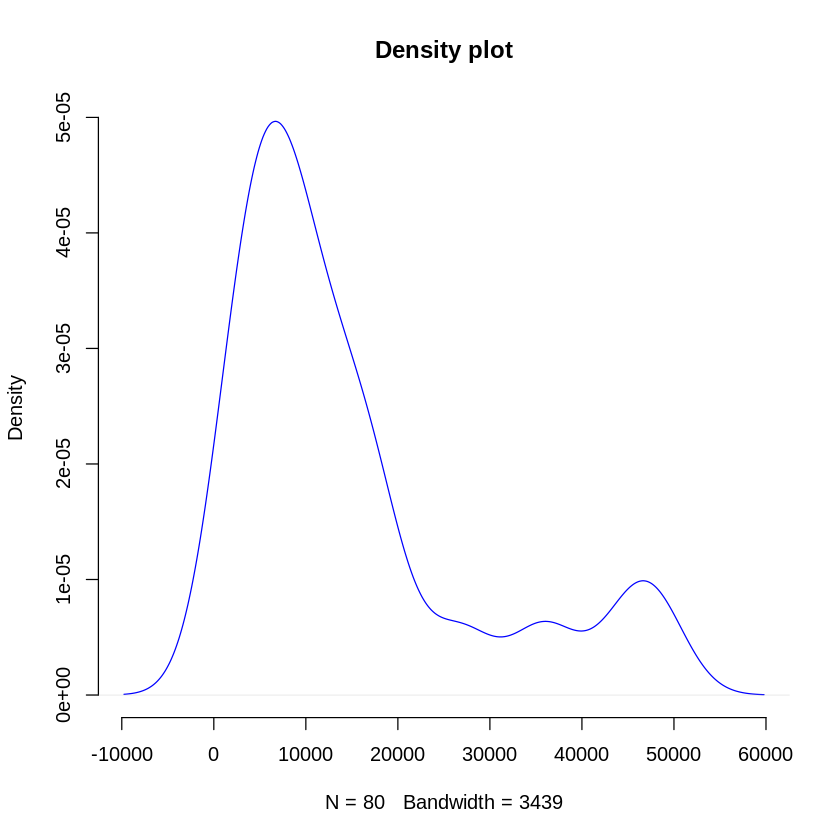

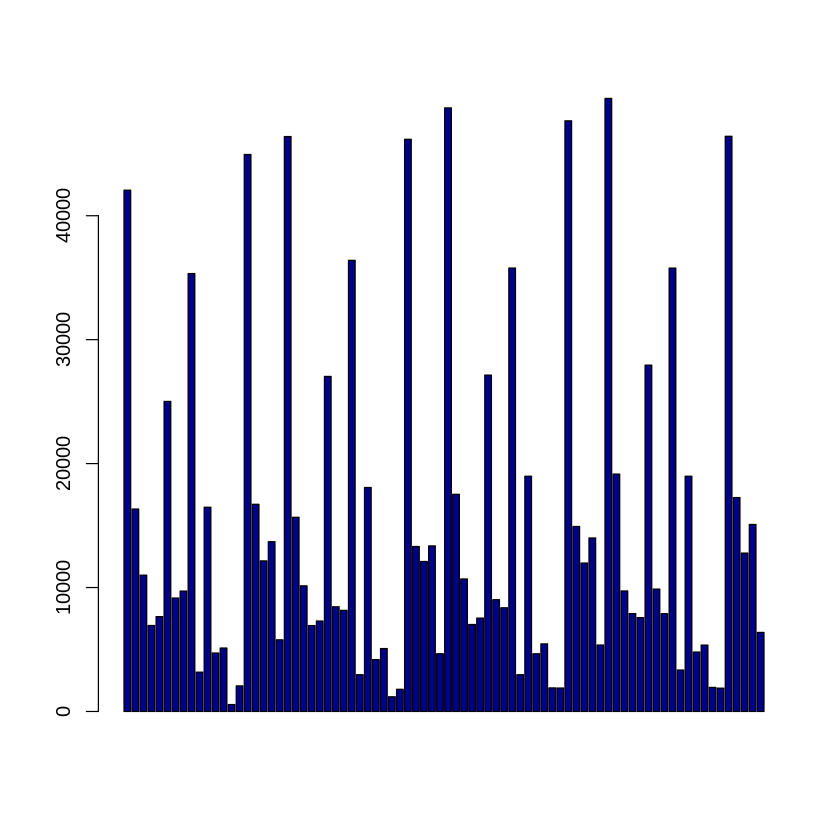

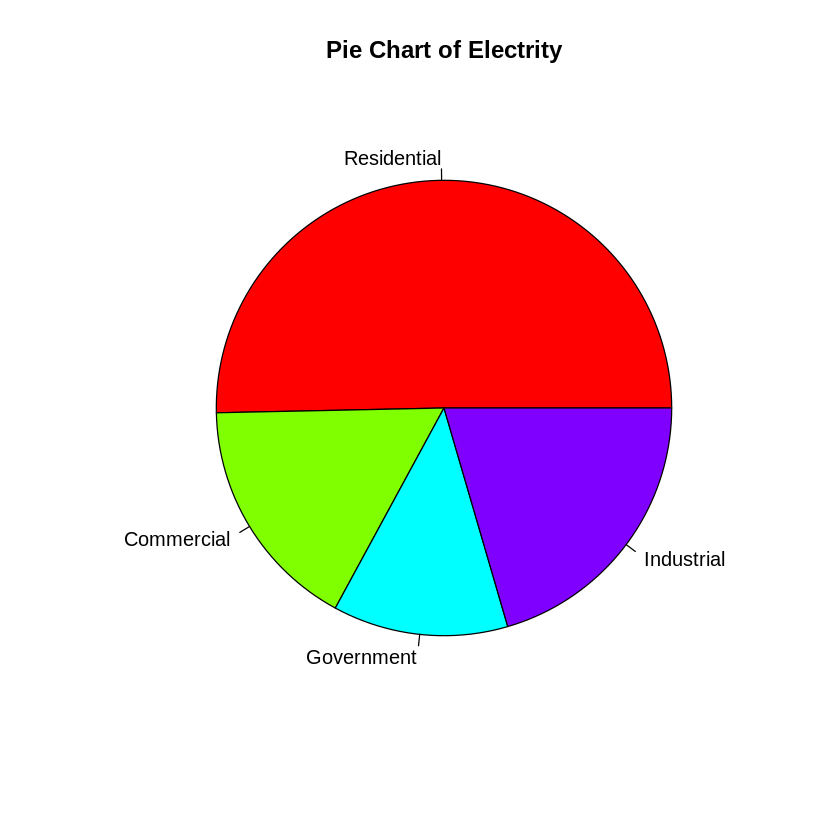

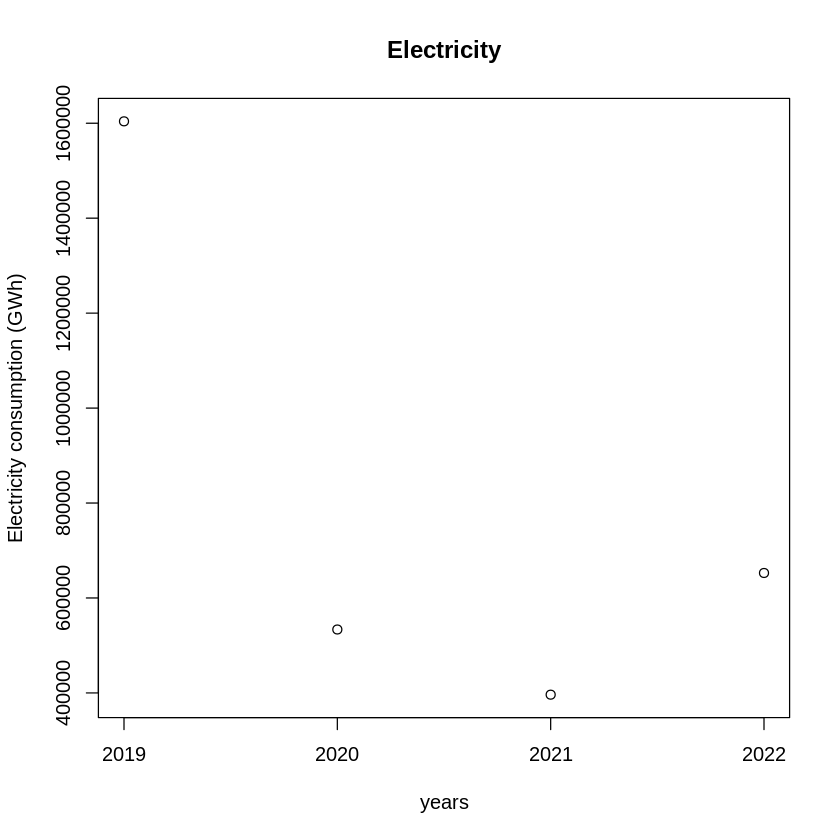

In [ ]:
library("readxl")
data <- read_excel("/content/electricity-consumption-2011-2022(2).xlsx")
categories <- c("Residential", "Commercial", "Government", "Industrial")
Vals <- c()
Mode <- function(x) {
  ux <- unique(x)
  ux[which.max(tabulate(match(x, ux)))]
}
# حساب المتوسطات
for(year in 2019:2022) {
  for (category in categories) {
      #تحديد الصفوف المطابقة للفئة والاتجاه والفترة الزمنية
      subset_data <- subset(data, `Consumption category` == category & Year == year)
      subset_data_for_cor <- subset(data, `Consumption category` == category)
      if(year==2019) { # الشرط هذا حطيته لأن مصفوفة فالس تخزن المحموعة مرة وحدة في كل كانيقوري وما ينفع تضيف قيمة في كل سنة لأنها بكل كاتيجوري تجمع بيانات السنة معها فشغلها يكون بسنة وحدة
        Vals <- append(Vals, sum(subset_data_for_cor$`Electricity consumption (GWh)`))
      }
      #print(subset_data)
      #print(subset_data$`Electricity consumption (GWh)`)
      column <- subset_data$`Electricity consumption (GWh)`
      column_for_cor <- subset_data_for_cor$`Electricity consumption (GWh)`
      res <- quantile(subset_data$`Electricity consumption (GWh)`, prob=c(.25,.5,.75), type=1)
      #print(t.test(column)) # When Needed, Get Normalization of a high filtered data
      # طباعة النتيجة
      print(Mode(column))
      cat(paste("Year:", year, "|", category,": {Average: ", mean(column), ", Variance: ", var(column), ", Standard Deviation:",sqrt(var(column)),"Correlation:",cor(column_for_cor, subset_data_for_cor$Year), ", Median:", median(column), ", IQR:", IQR(column), "Normalization:" , (sum(column) - mean(column)) / sqrt(var(column)), "Quartiles: {", res[1], ",", res[2], ",", res[3], "}", "Mode:", Mode(column), "}\n"))



  }
}
subset_data <- subset(data, Year > 2018)# تأخذجزء من البيانات بناء على الشروط بمقام الفلتره
print(t.test(subset_data$`Electricity consumption (GWh)`, var.equal = TRUE))
years <- c(2019,2020,2021,2022)

hist(subset_data$`Electricity consumption (GWh)`)
barplot(Vals, names.arg = years, xlab = "Year", ylab = "Value", main = "Custom Histogram")# هستوقرام خاص يدوي
boxplot(subset_data$`Electricity consumption (GWh)`)
den <- density(subset_data$`Electricity consumption (GWh)`)

plot(den, frame = FALSE, col = "blue",main = "Density plot")


barplot(subset_data$`Electricity consumption (GWh)`, col="darkblue")
pie(Vals, labels = categories, main="Pie Chart of Electrity", col=rainbow(4))
plot(years, Vals, main="Electricity", ylab="Electricity consumption (GWh)", xaxt = "n")
axis(1, at = years , labels =years)